<a href="https://colab.research.google.com/github/Ullas2534/Projects/blob/main/OCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/OCD Patient Dataset_ Demographics & Clinical Data.csv")

In [ ]:
df.head()

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1252 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

In [ ]:
df.fillna(method='ffill', inplace=True)
print(df.isnull().sum())

# Display the data types
print(df.dtypes)

Patient ID                       0
Age                              0
Gender                           0
Ethnicity                        0
Marital Status                   0
Education Level                  0
OCD Diagnosis Date               0
Duration of Symptoms (months)    0
Previous Diagnoses               0
Family History of OCD            0
Obsession Type                   0
Compulsion Type                  0
Y-BOCS Score (Obsessions)        0
Y-BOCS Score (Compulsions)       0
Depression Diagnosis             0
Anxiety Diagnosis                0
Medications                      0
dtype: int64
Patient ID                        int64
Age                               int64
Gender                           object
Ethnicity                        object
Marital Status                   object
Education Level                  object
OCD Diagnosis Date               object
Duration of Symptoms (months)     int64
Previous Diagnoses               object
Family History of OCD           

<ipython-input-38-8f42114d8746>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
# Convert categorical variables to 'category' type
categorical_cols = ['Gender', 'Ethnicity', 'Marital Status', 'Education Level',
                    'Previous Diagnoses', 'Family History of OCD',
                    'Obsession Type', 'Compulsion Type',
                    'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications']
for col in categorical_cols:
    df[col] = df[col].astype('category')


In [ ]:
# Analyze demographic data
demographics = df[['Age', 'Gender', 'Ethnicity', 'Marital Status', 'Education Level']]
print(demographics.describe(include='all'))

# Analyze clinical data
clinical_data = df[['Duration of Symptoms (months)', 'Previous Diagnoses',
                     'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
                     'Depression Diagnosis', 'Anxiety Diagnosis']]
print(clinical_data.describe())



                Age Gender  Ethnicity Marital Status Education Level
count   1500.000000   1500       1500           1500            1500
unique          NaN      2          4              3               4
top             NaN   Male  Caucasian         Single    Some College
freq            NaN    753        398            511             394
mean      46.781333    NaN        NaN            NaN             NaN
std       16.830321    NaN        NaN            NaN             NaN
min       18.000000    NaN        NaN            NaN             NaN
25%       32.000000    NaN        NaN            NaN             NaN
50%       47.000000    NaN        NaN            NaN             NaN
75%       61.000000    NaN        NaN            NaN             NaN
max       75.000000    NaN        NaN            NaN             NaN
       Duration of Symptoms (months)  Y-BOCS Score (Obsessions)  \
count                    1500.000000                1500.000000   
mean                      121.745333  

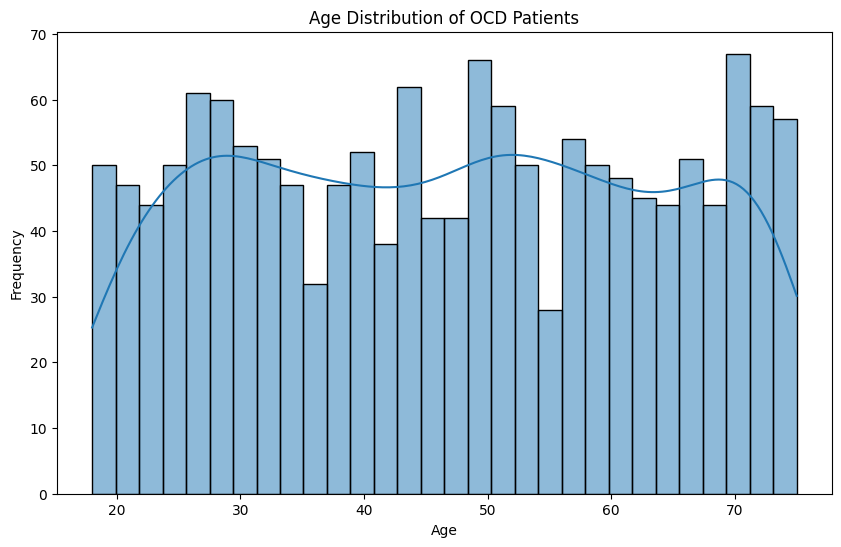

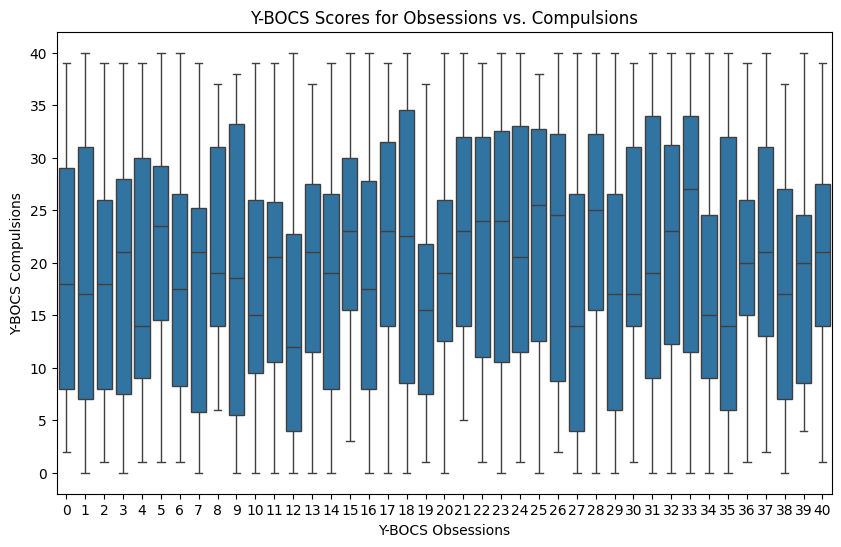

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of age
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of OCD Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Severity of symptoms
plt.figure(figsize=(10, 6))
sns.boxplot(x='Y-BOCS Score (Obsessions)', y='Y-BOCS Score (Compulsions)', data=df)
plt.title('Y-BOCS Scores for Obsessions vs. Compulsions')
plt.xlabel('Y-BOCS Obsessions')
plt.ylabel('Y-BOCS Compulsions')
plt.show()




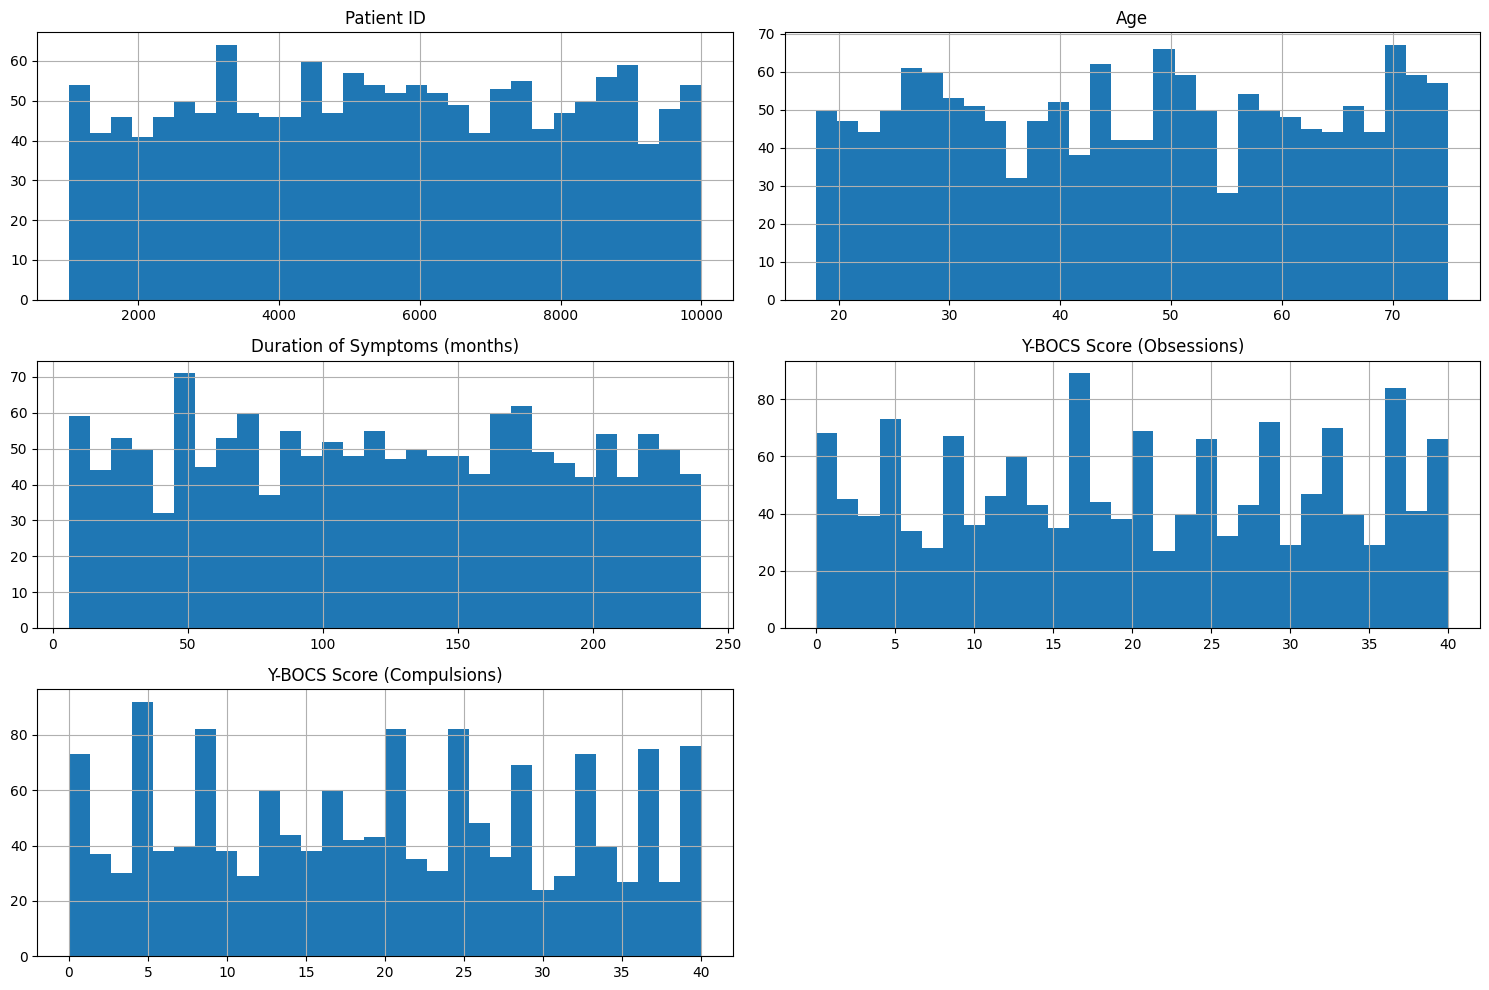

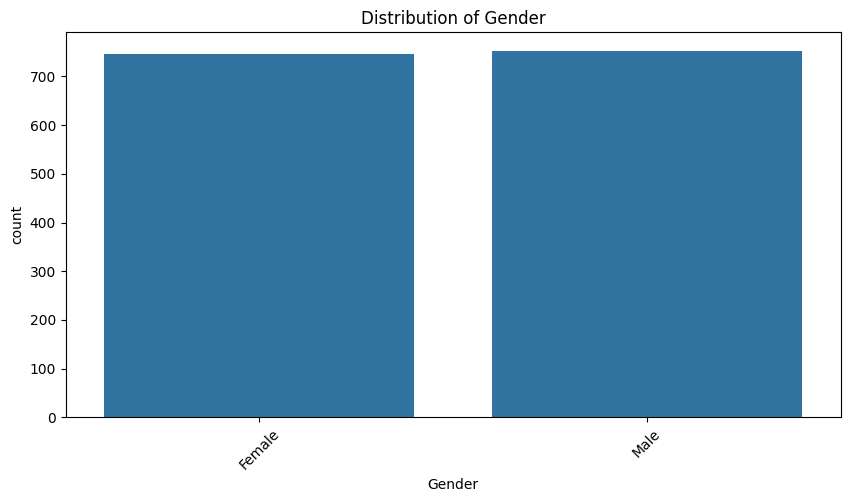

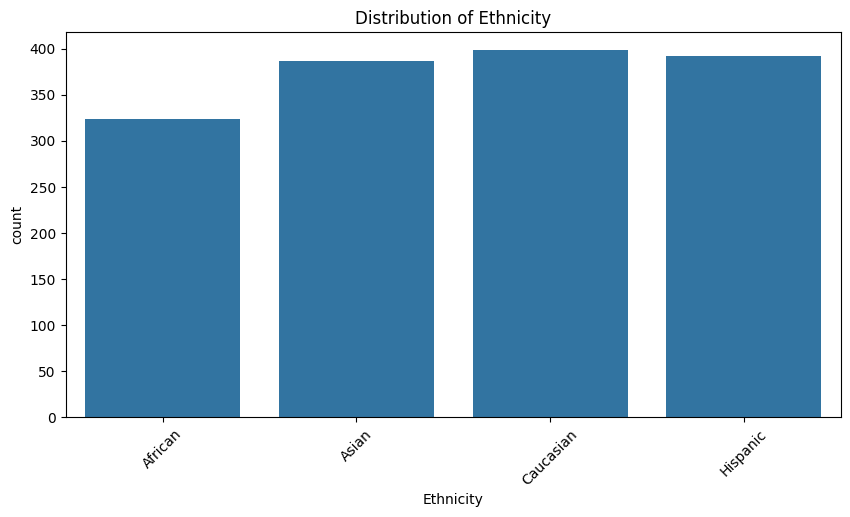

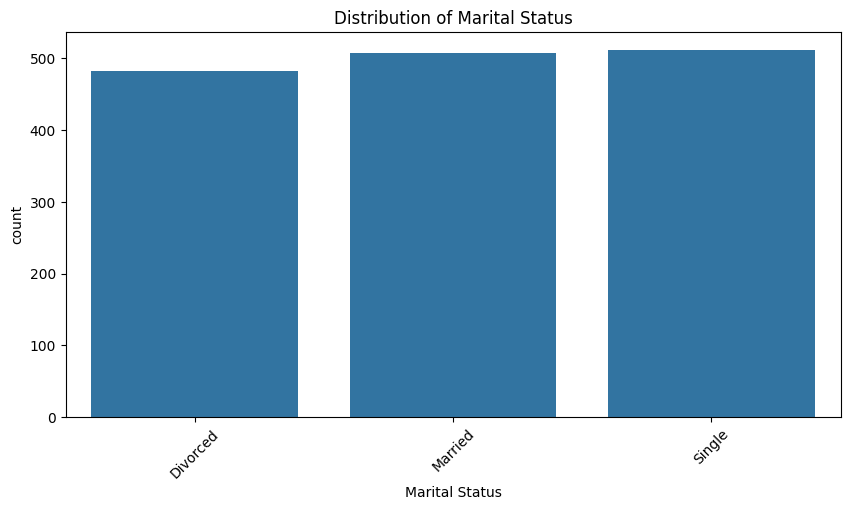

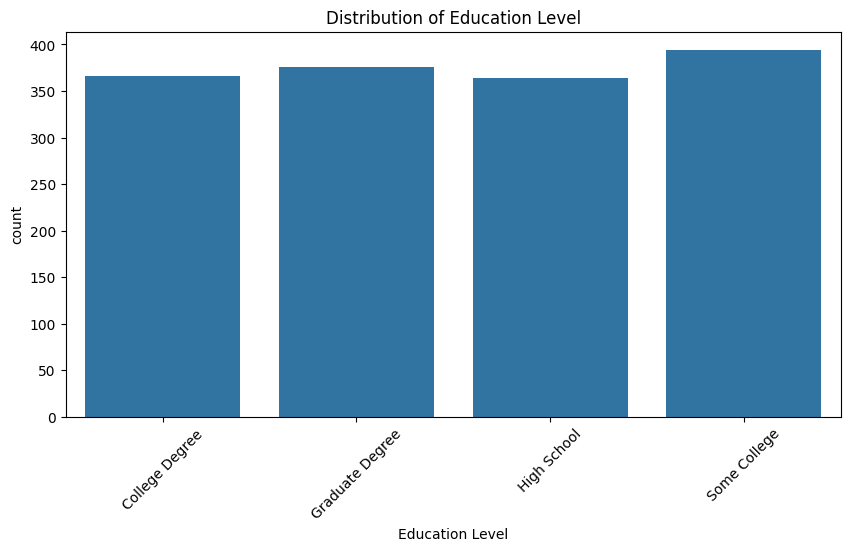

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Count plots for categorical features
categorical_cols = ['Gender', 'Ethnicity', 'Marital Status', 'Education Level']
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


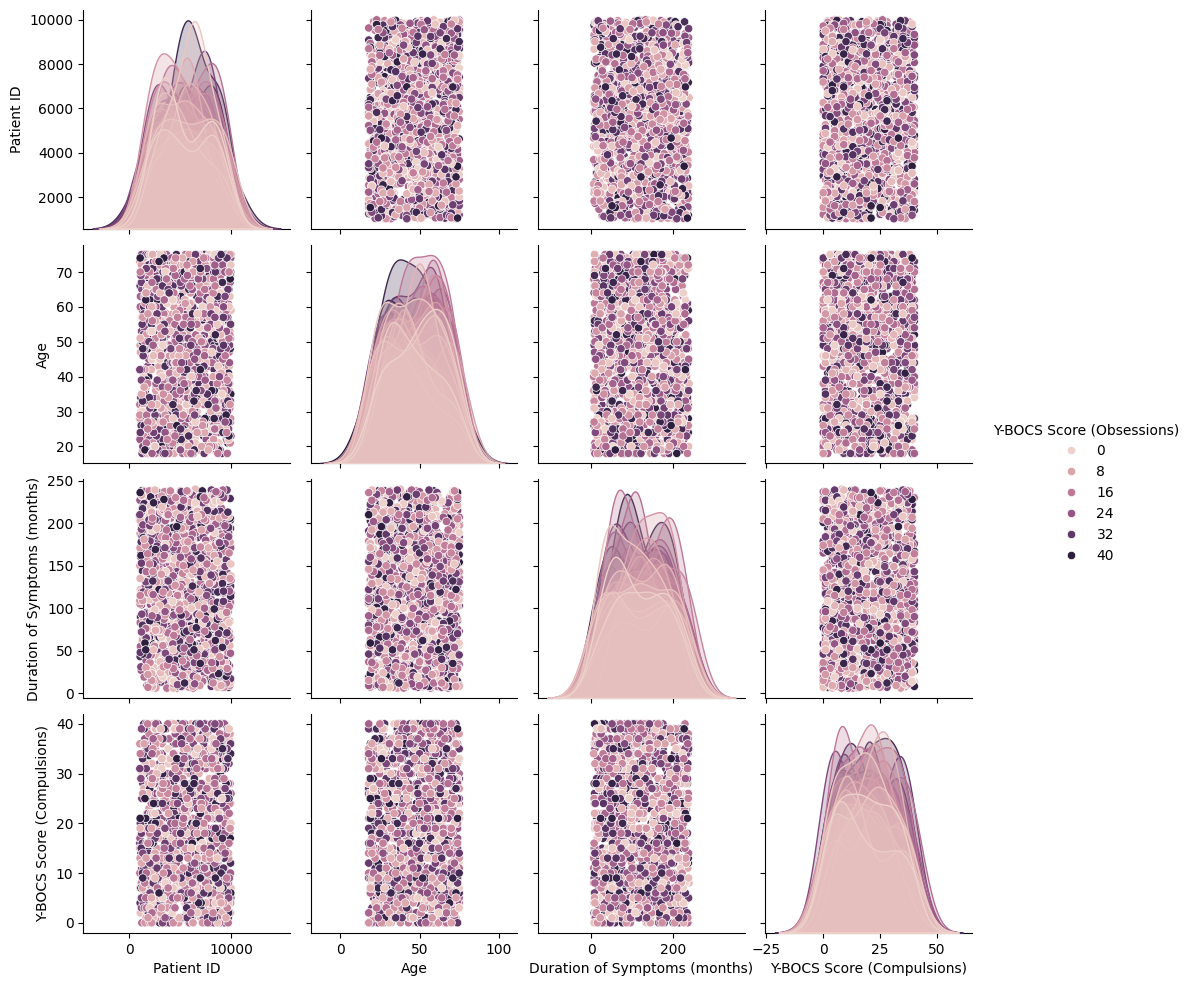

In [ ]:
# Pairplot for numerical features
sns.pairplot(df, hue='Y-BOCS Score (Obsessions)', diag_kind='kde')
plt.show()




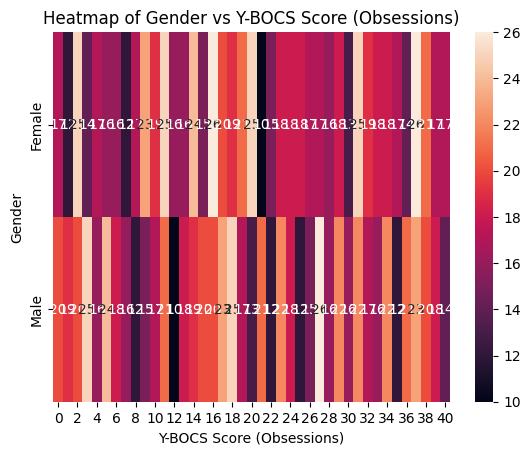

In [ ]:
sns.heatmap(pd.crosstab(df['Gender'], df['Y-BOCS Score (Obsessions)']), annot=True, fmt='d')
plt.title('Heatmap of Gender vs Y-BOCS Score (Obsessions)')
plt.show()


<ipython-input-30-b83051c97818>:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df['Patient ID'] = pd.to_datetime(df['Patient ID'], errors='ignore')


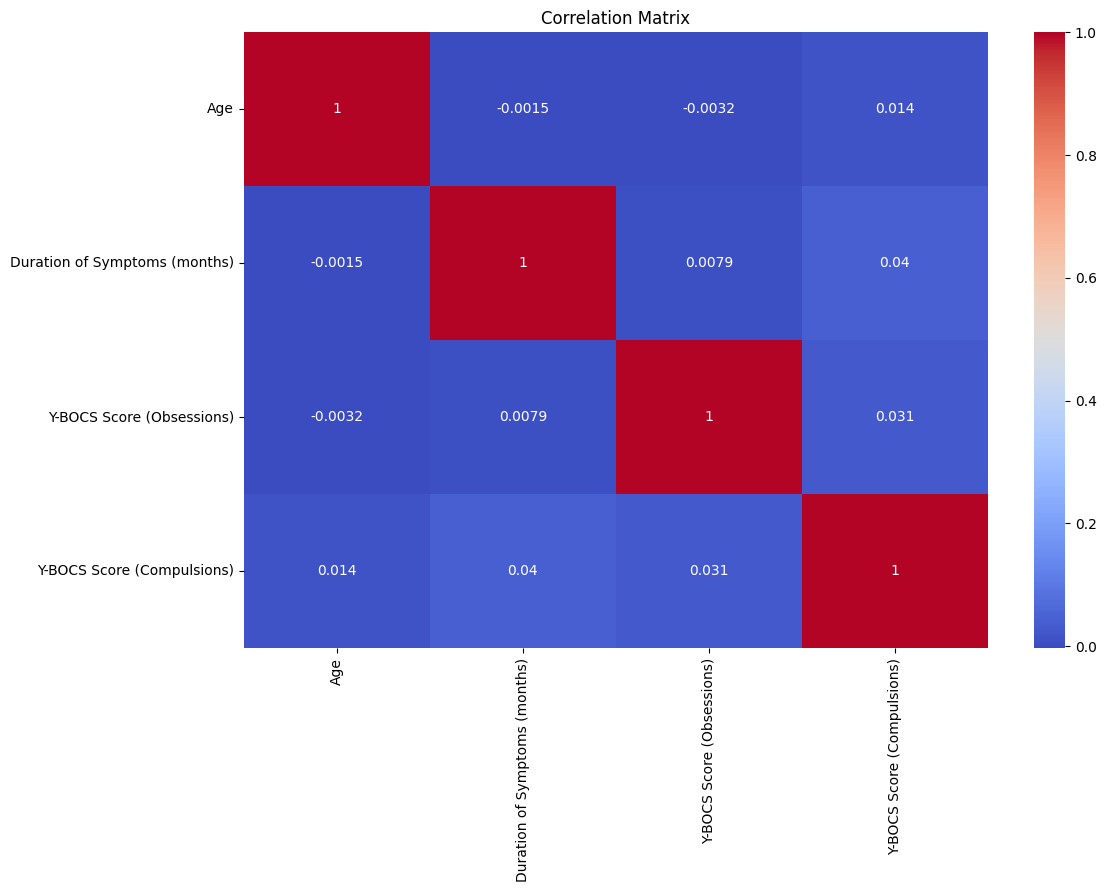

In [ ]:
# Correlation matrix

# Convert 'Patient ID' column to datetime if it's a date
df['Patient ID'] = pd.to_datetime(df['Patient ID'], errors='ignore')

# Select only numerical features for correlation
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



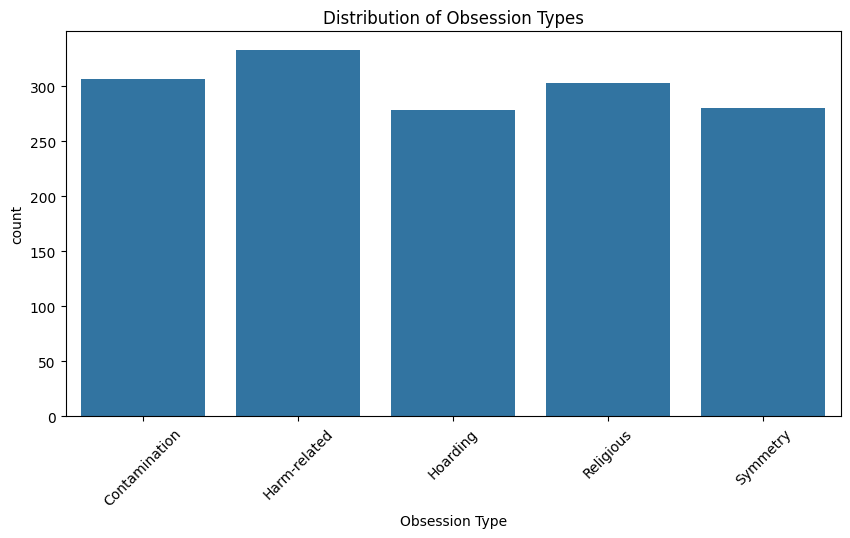

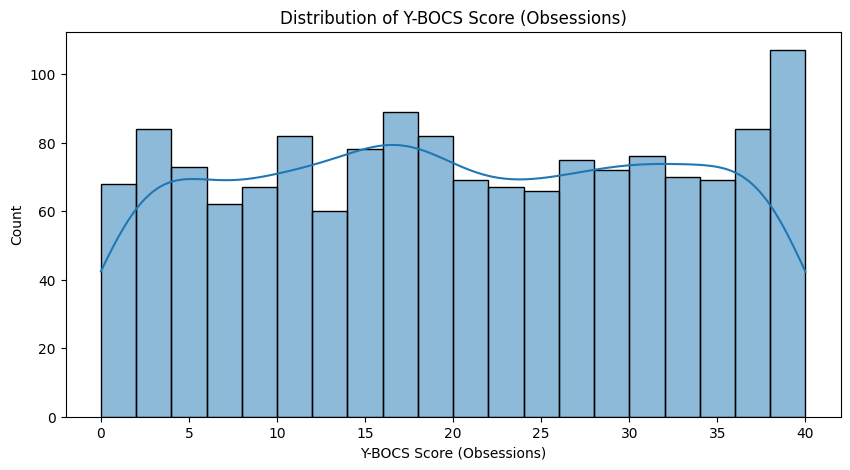

In [ ]:
# Count plot for a specific categorical feature
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Obsession Type')
plt.title('Distribution of Obsession Types')
plt.xticks(rotation=45)
plt.show()

# Distribution of the target variable
plt.figure(figsize=(10, 5))
sns.histplot(df['Y-BOCS Score (Obsessions)'], bins=20, kde=True)
plt.title('Distribution of Y-BOCS Score (Obsessions)')
plt.show()


      Treatment Method  Remission Rate (%)  Relapse Rate (%)
0                SSRIs                  50                60
1            CBT (ERP)                  70                25
2  Combination Therapy                  75                30


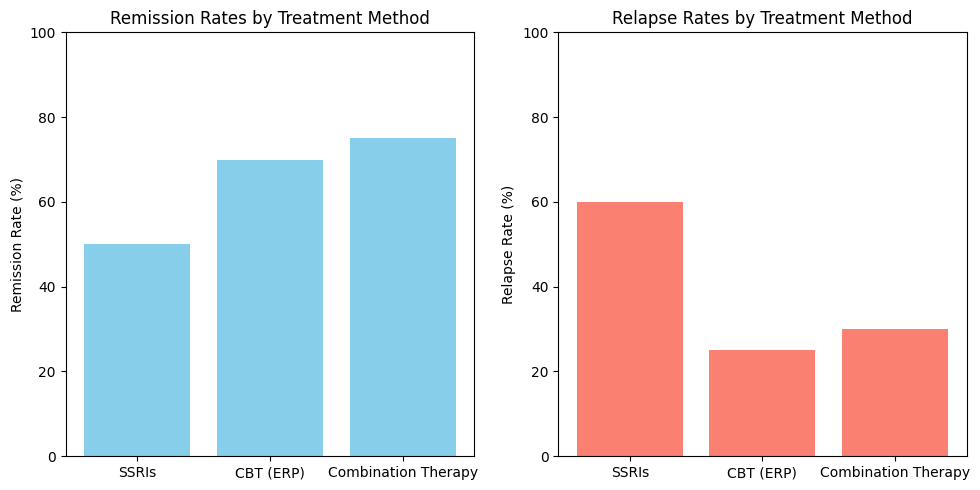

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame to store treatment methods and their statistics
data = {
    'Treatment Method': ['SSRIs', 'CBT (ERP)', 'Combination Therapy'],
    'Remission Rate (%)': [50, 70, 75],  # Average estimates
    'Relapse Rate (%)': [60, 25, 30]     # Average estimates
}

treatment_df = pd.DataFrame(data)

# Display the DataFrame
print(treatment_df)

# Plotting Remission and Relapse Rates
plt.figure(figsize=(10, 5))

# Bar plot for Remission Rates
plt.subplot(1, 2, 1)
plt.bar(treatment_df['Treatment Method'], treatment_df['Remission Rate (%)'], color='skyblue')
plt.title('Remission Rates by Treatment Method')
plt.ylabel('Remission Rate (%)')
plt.ylim(0, 100)

# Bar plot for Relapse Rates
plt.subplot(1, 2, 2)
plt.bar(treatment_df['Treatment Method'], treatment_df['Relapse Rate (%)'], color='salmon')
plt.title('Relapse Rates by Treatment Method')
plt.ylabel('Relapse Rate (%)')
plt.ylim(0, 100)

# Show plots
plt.tight_layout()
plt.show()

